Hệ số tương quan giữa Study Hours và Exam Score: 0.7178


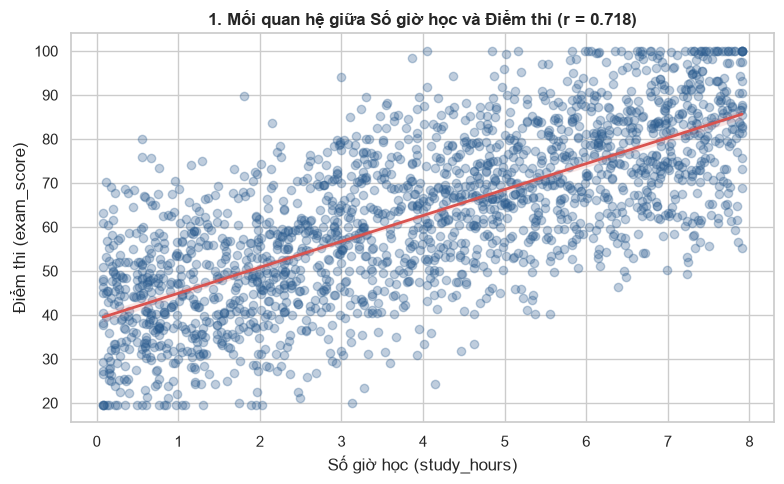


--- Thống kê theo Nhóm Số giờ học ---
  study_hours_group  count       mean  median        std
0           < 2 giờ   5012  44.729194    44.6  13.494608
1         2 - 4 giờ   4902  56.543631    56.4  14.065031
2         4 - 6 giờ   5097  68.653384    68.8  13.734110
3         6 - 8 giờ   4989  79.971658    80.3  12.933127


C:\Users\PC\AppData\Local\Temp\ipykernel_9172\2986485223.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=mean_study, x='study_hours_group', y='mean', palette='Blues_r')


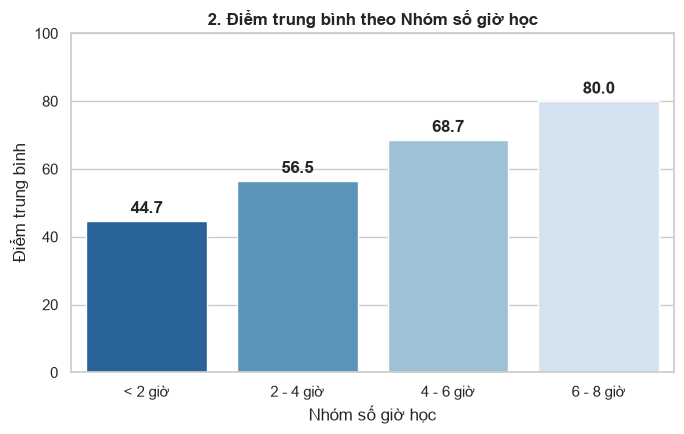


Hệ số tương quan giữa Attendance và Exam Score: 0.3089

--- Thống kê theo Tỷ lệ Điểm danh ---
      attendance_group  count       mean  median        std
0          Thấp (<60%)   6646  55.745344    55.9  18.047972
1  Trung bình (60-80%)   6704  62.595339    62.6  18.229101
2           Cao (>80%)   6650  69.194254    69.6  18.011769


C:\Users\PC\AppData\Local\Temp\ipykernel_9172\2986485223.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=mean_att, x='attendance_group', y='mean', palette='Greens_r')


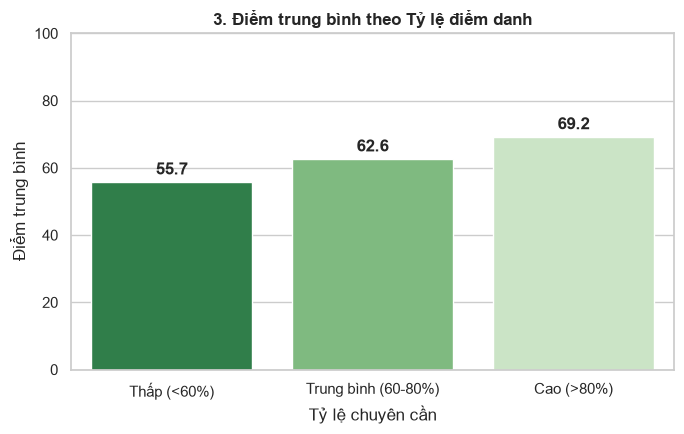

C:\Users\PC\AppData\Local\Temp\ipykernel_9172\2986485223.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attendance_group', y='exam_score', palette='Greens')


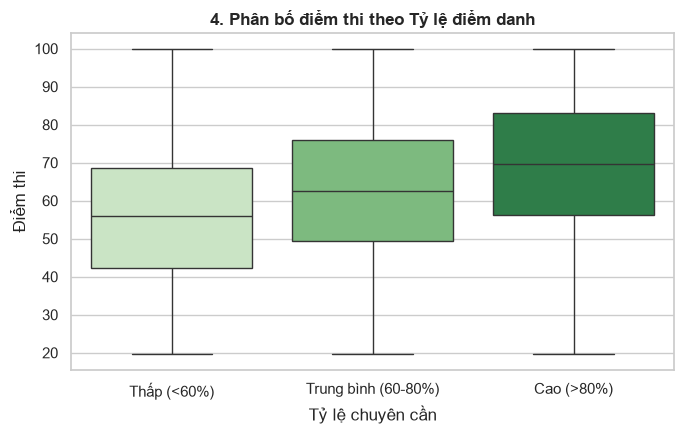


--- Thống kê theo Phương pháp Học tập ---
    study_method  count       mean  median        std
0       coaching   4036  68.550963   68.80  18.415747
2          mixed   3894  64.242879   64.60  18.419535
1    group study   3922  60.967482   61.15  18.525262
3  online videos   4069  60.151694   59.90  18.748836
4     self-study   4079  58.729919   58.70  18.766427


C:\Users\PC\AppData\Local\Temp\ipykernel_9172\2986485223.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=mean_method, x='study_method', y='mean', palette='Oranges_r')


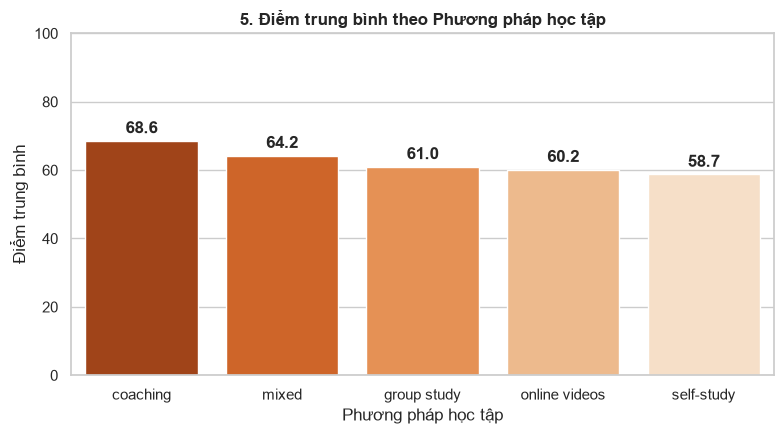

C:\Users\PC\AppData\Local\Temp\ipykernel_9172\2986485223.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='study_method', y='exam_score', order=mean_method['study_method'], palette='Oranges')


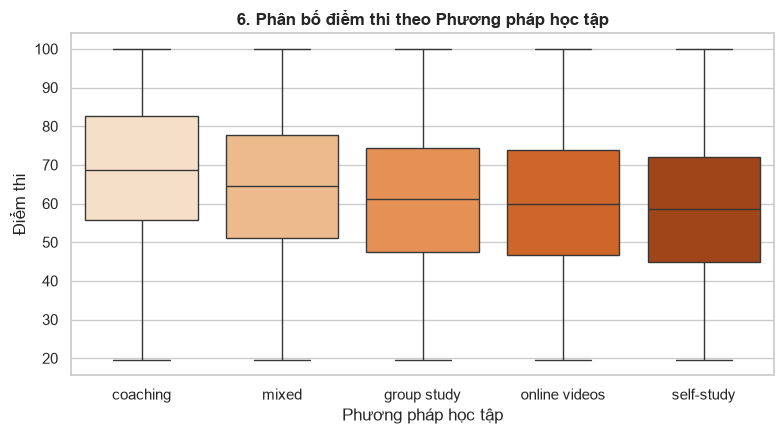


[Lưu ý]: Cột 'sample_papers_practiced' không xuất hiện trong file dữ liệu thực tế.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('Exam_Score_Prediction.csv')

# ====================================================
# 1. STUDY HOURS -> EXAM SCORE
# ====================================================

# Tính hệ số tương quan Pearson
corr_study = df['study_hours'].corr(df['exam_score'])
print(f"Hệ số tương quan giữa Study Hours và Exam Score: {corr_study:.4f}")

# Biểu đồ Scatter Plot (lấy mẫu 2,000 điểm để hiển thị rõ ràng)
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(2000, random_state=42), x='study_hours', y='exam_score',
            scatter_kws={'alpha': 0.3, 'color': '#2b5c8f'}, line_kws={'color': '#d9534f', 'linewidth': 2})
plt.title(f'1. Mối quan hệ giữa Số giờ học và Điểm thi (r = {corr_study:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Số giờ học (study_hours)')
plt.ylabel('Điểm thi (exam_score)')
plt.tight_layout()
plt.show()

# Chia nhóm số giờ học & Tính điểm trung bình
df['study_hours_group'] = pd.cut(df['study_hours'], bins=[0, 2, 4, 6, 8], labels=['< 2 giờ', '2 - 4 giờ', '4 - 6 giờ', '6 - 8 giờ'])
mean_study = df.groupby('study_hours_group', observed=False)['exam_score'].agg(['count', 'mean', 'median', 'std']).reset_index()
print("\n--- Thống kê theo Nhóm Số giờ học ---")
print(mean_study)

# Biểu đồ Bar Chart cho nhóm giờ học
plt.figure(figsize=(7, 4.5))
ax1 = sns.barplot(data=mean_study, x='study_hours_group', y='mean', palette='Blues_r')
plt.title('2. Điểm trung bình theo Nhóm số giờ học', fontsize=12, fontweight='bold')
plt.xlabel('Nhóm số giờ học')
plt.ylabel('Điểm trung bình')
plt.ylim(0, 100)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


# ====================================================
# 2. ATTENDANCE -> EXAM SCORE
# ====================================================

# Tính hệ số tương quan
corr_att = df['class_attendance'].corr(df['exam_score'])
print(f"\nHệ số tương quan giữa Attendance và Exam Score: {corr_att:.4f}")

# Chia nhóm Tỷ lệ điểm danh
df['attendance_group'] = pd.cut(df['class_attendance'], bins=[0, 60, 80, 100], labels=['Thấp (<60%)', 'Trung bình (60-80%)', 'Cao (>80%)'])
mean_att = df.groupby('attendance_group', observed=False)['exam_score'].agg(['count', 'mean', 'median', 'std']).reset_index()
print("\n--- Thống kê theo Tỷ lệ Điểm danh ---")
print(mean_att)

# Biểu đồ Bar Chart chuyên cần
plt.figure(figsize=(7, 4.5))
ax2 = sns.barplot(data=mean_att, x='attendance_group', y='mean', palette='Greens_r')
plt.title('3. Điểm trung bình theo Tỷ lệ điểm danh', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ lệ chuyên cần')
plt.ylabel('Điểm trung bình')
plt.ylim(0, 100)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ Boxplot chuyên cần
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x='attendance_group', y='exam_score', palette='Greens')
plt.title('4. Phân bố điểm thi theo Tỷ lệ điểm danh', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ lệ chuyên cần')
plt.ylabel('Điểm thi')
plt.tight_layout()
plt.show()


# ====================================================
# 3. STUDY METHOD -> EXAM SCORE
# ====================================================

# So sánh điểm trung bình giữa các phương pháp học
mean_method = df.groupby('study_method')['exam_score'].agg(['count', 'mean', 'median', 'std']).reset_index().sort_values('mean', ascending=False)
print("\n--- Thống kê theo Phương pháp Học tập ---")
print(mean_method)

# Biểu đồ Bar Chart phương pháp học
plt.figure(figsize=(8, 4.5))
ax3 = sns.barplot(data=mean_method, x='study_method', y='mean', palette='Oranges_r')
plt.title('5. Điểm trung bình theo Phương pháp học tập', fontsize=12, fontweight='bold')
plt.xlabel('Phương pháp học tập')
plt.ylabel('Điểm trung bình')
plt.ylim(0, 100)
for p in ax3.patches:
    ax3.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ Boxplot phương pháp học
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x='study_method', y='exam_score', order=mean_method['study_method'], palette='Oranges')
plt.title('6. Phân bố điểm thi theo Phương pháp học tập', fontsize=12, fontweight='bold')
plt.xlabel('Phương pháp học tập')
plt.ylabel('Điểm thi')
plt.tight_layout()
plt.show()


# ====================================================
# 4. SAMPLE PAPERS PRACTICED -> EXAM SCORE
# ====================================================

if 'sample_papers_practiced' in df.columns:
    corr_papers = df['sample_papers_practiced'].corr(df['exam_score'])
    print(f"\nHệ số tương quan sample_papers_practiced: {corr_papers:.4f}")
else:
    print("\n[Lưu ý]: Cột 'sample_papers_practiced' không xuất hiện trong file dữ liệu thực tế.")